# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Iniego, Angel Nicole
- _Student No._: 2024-09622
- _Section_: THR-TX-_

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

<img src="Figures/04_SingleAxis.png" alt="Combined Plots" width=100% caption="The Combined Plots">
Figure 1. Combined Plots for Varying Difference Formulas.

<img src="Figures/04_DifferenceApproximations.png" alt="Combined Plots" width=100% caption="The Combined Plots">
Figure 2. MAE vs. the step differences.

### Report discussion
The three curves in Figure 1 fall on straight lines in log-log space, confirming the theoretical error orders derived from their Taylor expansions. Forward and backward differences remain appropriate at domain boundaries, for one-sided or real-time/streaming data where only past or future values are available, or when function evaluations are expensive and only one additional point can be afforded.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

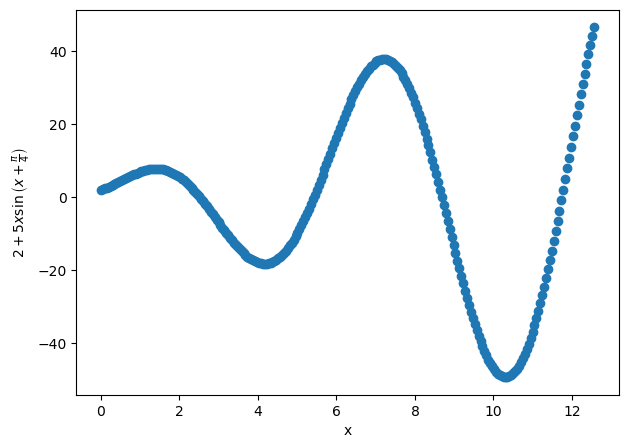

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4)
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [3]:
def analytical(x):
    return 5*(np.sin(x+np.pi/4) + x*np.cos(x+np.pi/4))
    
def forward(x,h):
    return x[:-1], (f_0(x[1:])- f_0(x[:-1])) / h

def backward(x,h):
    return x[1:], (f_0(x[1:]) - f_0(x[:-1])) / h

def central(x,h):
    return x[1:-1], (f_0(x[2:]) - f_0(x[:-2])) / (2*h)

In [ ]:
# These values will be used througout the problem
x = np.linspace(0, 4*np.pi, 257)
h = x[1]-x[0] 

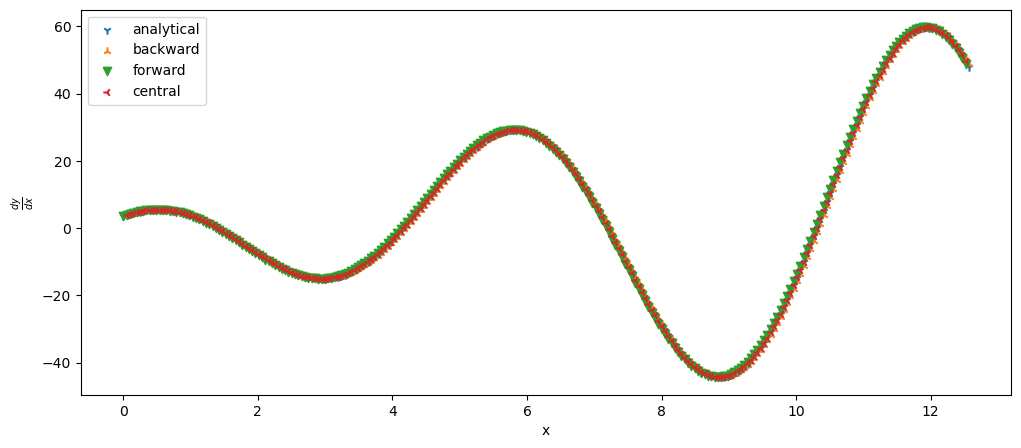

In [12]:
# Plotting in a single axis
fig, ax = plt.subplots(figsize=(12,5))
ax.scatter(x,analytical(x), label="analytical", marker='1')
ax.scatter(backward(x,h)[0], backward(x,h)[1], label="backward", marker='2')
ax.scatter(forward(x,h)[0],forward(x,h)[1], label="forward", marker='v')
ax.scatter(central(x,h)[0],central(x,h)[1], label="central", marker='3')
ax.set_xlabel("x")
ax.set_ylabel(r"$\frac{dy}{dx}$")
ax.legend()
fig.show()
#fig.savefig('04_SingleAxis.png')

In [20]:
# Getting the errors for each of the approximations compared
# to the analytically derived function.

# For the base grid (257 points), get the mean absolute error (MAE)
# of each approximation vs. the analytically derived function.
x_f, dy_f = forward(x, h)
x_b, dy_b = backward(x, h)
x_c, dy_c = central(x, h)

mae_forward  = np.mean(np.abs(analytical(x_f) - dy_f))
mae_backward = np.mean(np.abs(analytical(x_b) - dy_b))
mae_central  = np.mean(np.abs(analytical(x_c) - dy_c))

print(f"h = {h:.5f}")
print(f"MAE (forward)  = {mae_forward:.6e}")
print(f"MAE (backward) = {mae_backward:.6e}")
print(f"MAE (central)  = {mae_central:.6e}")

h = 0.04909
MAE (forward)  = 4.995543e-01
MAE (backward) = 5.005318e-01
MAE (central)  = 9.652198e-03


In [21]:
# Repeat the above step for increasing number of points (decreasing spacing)
# The strategy is to store the values on a list.
n_points_list = [64, 128, 256, 512, 1024, 2048, 4096, 8192]

h_list = []
mae_forward_list = []
mae_backward_list = []
mae_central_list = []

for n in n_points_list:
    x_n = np.linspace(0, 4*np.pi, n)
    h_n = x_n[1] - x_n[0]

    x_f, dy_f = forward(x_n, h_n)
    x_b, dy_b = backward(x_n, h_n)
    x_c, dy_c = central(x_n, h_n)

    mae_forward_list.append(np.mean(np.abs(analytical(x_f) - dy_f)))
    mae_backward_list.append(np.mean(np.abs(analytical(x_b) - dy_b)))
    mae_central_list.append(np.mean(np.abs(analytical(x_c) - dy_c)))

    h_list.append(h_n)

h_list = np.array(h_list)
mae_forward_list = np.array(mae_forward_list)
mae_backward_list = np.array(mae_backward_list)
mae_central_list = np.array(mae_central_list)

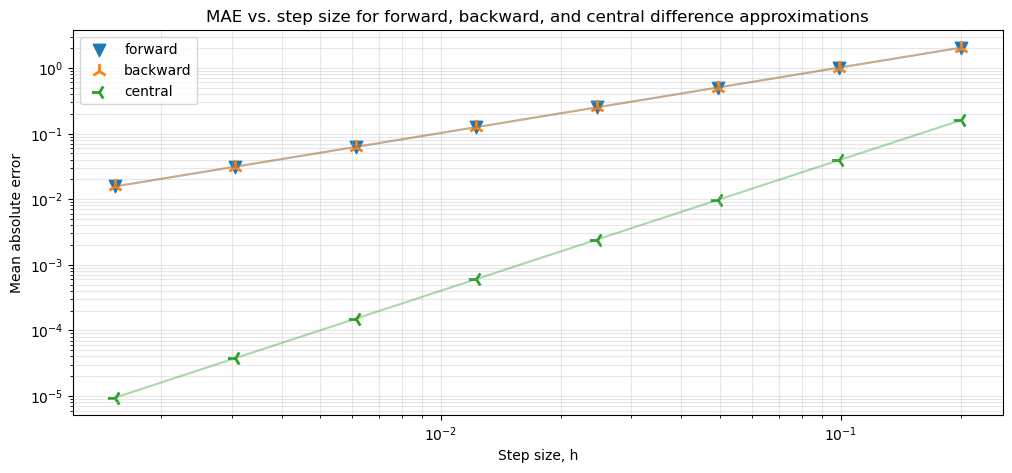

In [22]:
# (For the report) Make a plot of the mean absolute error vs the spacing between points.
# In this plot, there should be three curves:
# One for the forward, one for the backward, and one for the central difference approximation

fig, ax = plt.subplots(figsize=(12, 5))  # landscape aspect ratio

ax.scatter(h_list, mae_forward_list, label="forward", marker='v', s=80)
ax.scatter(h_list, mae_backward_list, label="backward", marker='2', s=120, linewidths=2)
ax.scatter(h_list, mae_central_list, label="central", marker='3', s=120, linewidths=2)

ax.plot(h_list, mae_forward_list, alpha=0.4)
ax.plot(h_list, mae_backward_list, alpha=0.4)
ax.plot(h_list, mae_central_list, alpha=0.4)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Step size, h")
ax.set_ylabel("Mean absolute error")
ax.set_title("MAE vs. step size for forward, backward, and central difference approximations")
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.show()
#fig.savefig('04_DifferenceApproximations.png')

#### Problem 1 code summary

The code approximates the first derivative of a function $f(x)=2+5x*sin(x+np.pi/4)$ using the forward, backward, and central finite-difference formulas, then compares each against the analytical derivative by computing the mean absolute error (MAE). 

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [ ]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

In [ ]:
x = np.linspace(1, 10, 10)
print(x)
print(np.roll(x, 1))
print(np.roll(x, -1))